In [3]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

from src.liar.dataset import load_liar_splits, LIAR_LABELS, LIAR_LABEL_NAMES

train_df, val_df, test_df = load_liar_splits()

LIAR processed splits already exist. Loading from disk.


In [4]:
# Dataset overview — size, null rates, and label encoding
import pandas as pd
import os

raw_dir = project_root / "data" / "raw" / "liar"

print("=== LIAR Raw Dataset (Official Splits) ===")
for split_file, split_name in [("train.tsv", "Train"), ("valid.tsv", "Val"), ("test.tsv", "Test")]:
    raw = pd.read_csv(
        raw_dir / split_file, sep="\t", header=None,
        names=["id","label","statement","subject","speaker","job_title",
               "state_info","party_affiliation","barely_true_counts",
               "false_counts","half_true_counts","mostly_true_counts",
               "pants_on_fire_counts","context"]
    )
    print(f"  {split_name}: {len(raw):,} rows")
    print(f"    Null counts — statement: {raw['statement'].isnull().sum()}, label: {raw['label'].isnull().sum()}")

print()
print("=== After Preprocessing (processed splits) ===")
total = len(train_df) + len(val_df) + len(test_df)
print(f"  Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}  Total: {total:,}")
print()
print("=== 6-Class Label Encoding ===")
for name, code in sorted(LIAR_LABELS.items(), key=lambda x: x[1]):
    print(f"  {code}  →  {name}")
print()

=== LIAR Raw Dataset (Official Splits) ===
  Train: 10,240 rows
    Null counts — statement: 0, label: 0
  Val: 1,284 rows
    Null counts — statement: 0, label: 0
  Test: 1,267 rows
    Null counts — statement: 0, label: 0

=== After Preprocessing (processed splits) ===
  Train: 10,240  Val: 1,284  Test: 1,267  Total: 12,791

=== 6-Class Label Encoding ===
  0  →  pants-fire
  1  →  false
  2  →  barely-true
  3  →  half-true
  4  →  mostly-true
  5  →  true



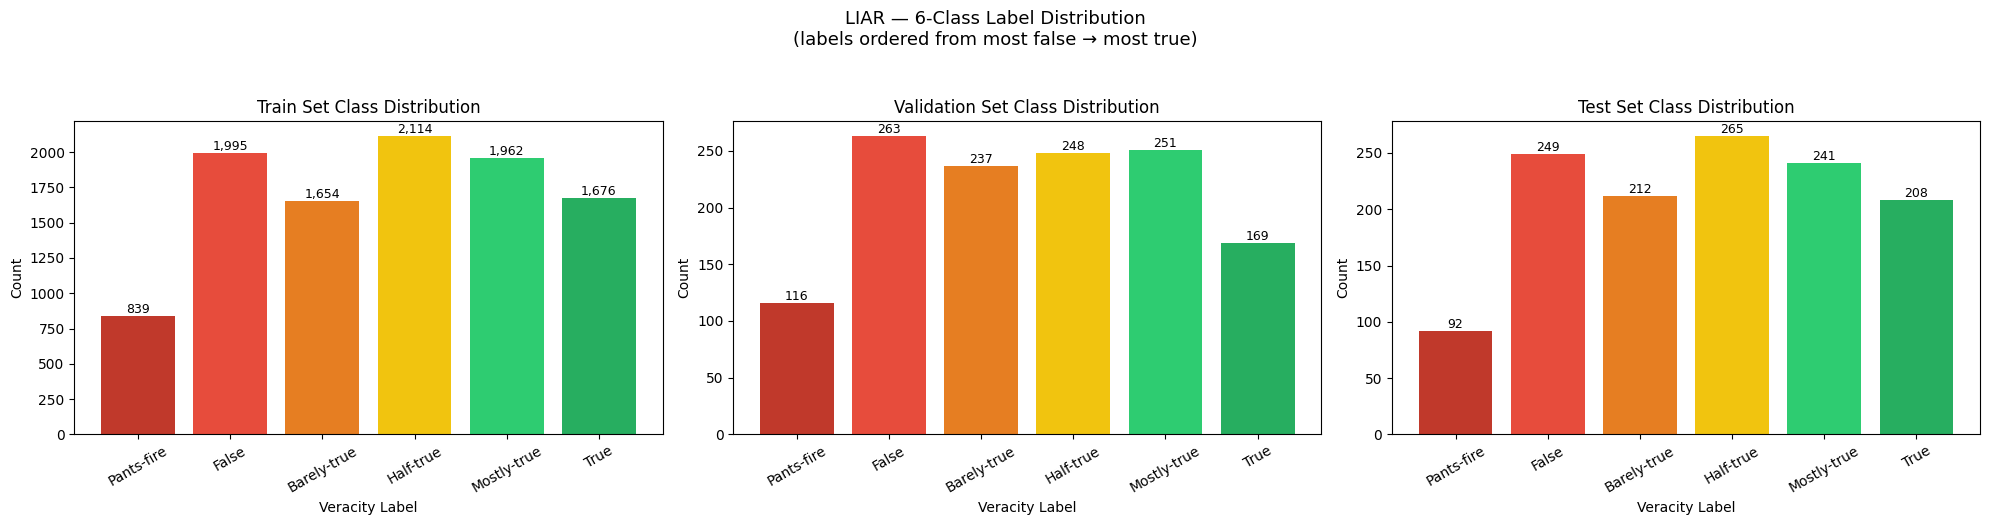

In [5]:
# Class distribution across all splits
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# 6-class palette: pants-fire=dark-red → true=dark-green
PALETTE = {
    0: "#c0392b",  # pants-fire  — darkest red
    1: "#e74c3c",  # false
    2: "#e67e22",  # barely-true — orange
    3: "#f1c40f",  # half-true   — yellow
    4: "#2ecc71",  # mostly-true
    5: "#27ae60",  # true        — darkest green
}
SHORT_NAMES = {
    0: "Pants-fire",
    1: "False",
    2: "Barely-true",
    3: "Half-true",
    4: "Mostly-true",
    5: "True",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (name, df) in zip(axes, [("Train", train_df), ("Validation", val_df), ("Test", test_df)]):
    counts = df["label"].value_counts().sort_index()
    bars = ax.bar(
        [SHORT_NAMES[l] for l in counts.index],
        counts.values,
        color=[PALETTE[l] for l in counts.index],
    )
    ax.set_title(f"{name} Set Class Distribution")
    ax.set_xlabel("Veracity Label")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    for bar in bars:
        ax.annotate(
            f"{int(bar.get_height()):,}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center", va="bottom", fontsize=9
        )

plt.suptitle(
    "LIAR — 6-Class Label Distribution\n"
    "(labels ordered from most false → most true)",
    fontsize=13, y=1.04
)
plt.tight_layout()
plt.show()

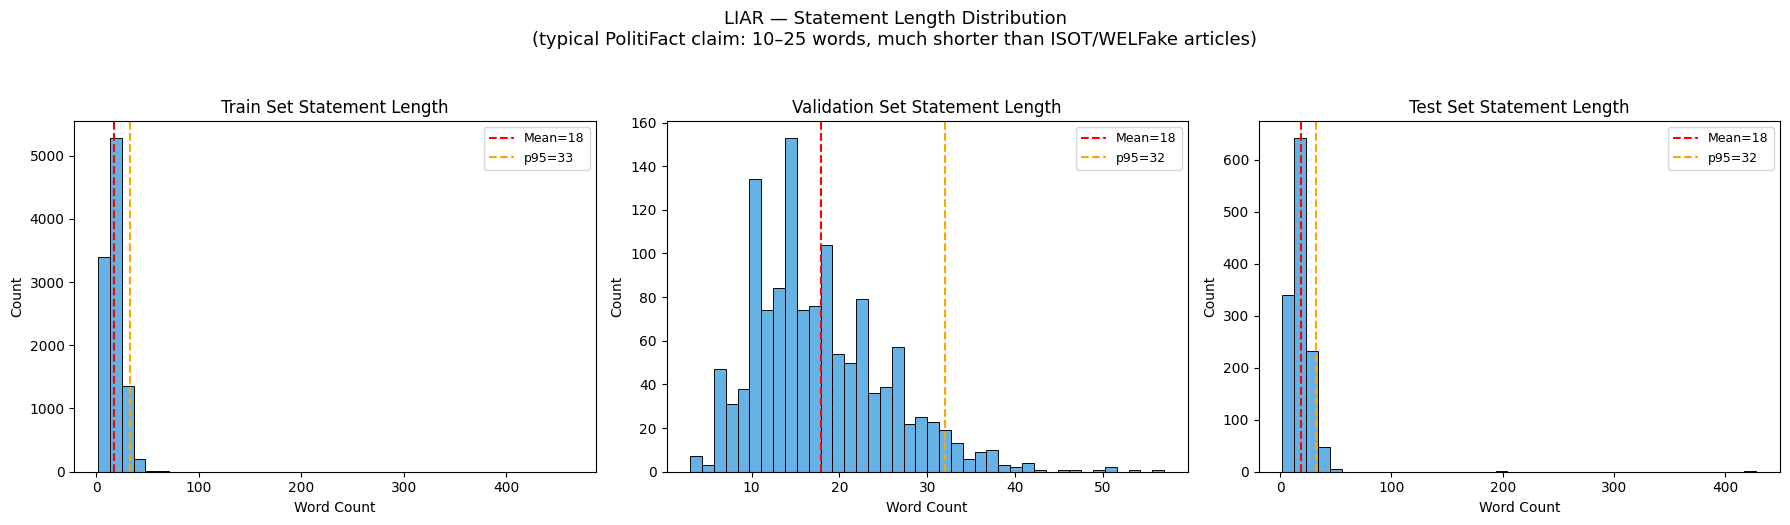

In [6]:
# Statement length distribution (LIAR texts are short ~18-word claims)
def plot_statement_length_distribution(train_df, val_df, test_df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, df) in zip(axes, [("Train", train_df.copy()), ("Validation", val_df.copy()), ("Test", test_df.copy())]):
        df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
        sns.histplot(df["text_length"], bins=40, ax=ax, color="#3498db")
        ax.axvline(df["text_length"].mean(), color="red", linestyle="--",
                   label=f"Mean={df['text_length'].mean():.0f}")
        ax.axvline(df["text_length"].quantile(0.95), color="orange", linestyle="--",
                   label=f"p95={df['text_length'].quantile(0.95):.0f}")
        ax.set_title(f"{name} Set Statement Length")
        ax.set_xlabel("Word Count")
        ax.legend(fontsize=9)
    plt.suptitle(
        "LIAR — Statement Length Distribution\n"
        "(typical PolitiFact claim: 10–25 words, much shorter than ISOT/WELFake articles)",
        fontsize=13, y=1.04
    )
    plt.tight_layout()
    plt.show()

plot_statement_length_distribution(train_df, val_df, test_df)

/tmp/ipykernel_73082/4046389195.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


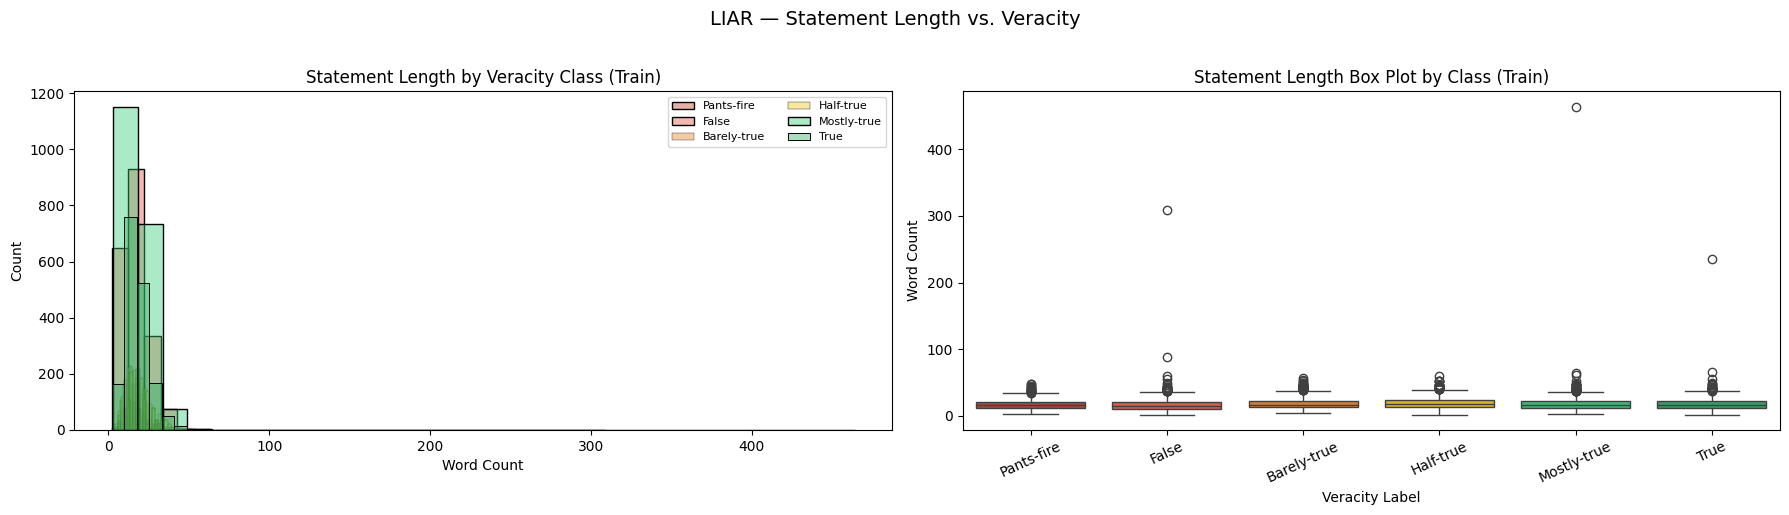

              count  mean   std  min   25%   50%   75%    max
label_name                                                   
Barely-true  1654.0  18.1   7.8  4.0  13.0  17.0  23.0   57.0
False        1995.0  16.9  10.1  2.0  11.0  15.0  21.0  309.0
Half-true    2114.0  18.7   8.0  2.0  13.0  18.0  23.8   60.0
Mostly-true  1962.0  18.4  12.7  3.0  12.2  17.0  22.0  464.0
Pants-fire    839.0  17.1   7.4  3.0  12.0  16.0  21.0   48.0
True         1676.0  17.9   9.2  2.0  12.0  16.0  22.0  235.0


In [7]:
# Statement length by veracity class
def plot_length_by_class(train_df):
    df = train_df.copy()
    df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
    df["label_name"] = df["label"].map(SHORT_NAMES)

    label_order = [SHORT_NAMES[i] for i in range(6)]
    colors = [PALETTE[i] for i in range(6)]

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Overlapping histograms
    for lbl, color in PALETTE.items():
        subset = df[df["label"] == lbl]["text_length"]
        sns.histplot(subset, bins=30, ax=axes[0], color=color,
                     alpha=0.4, label=SHORT_NAMES[lbl])
    axes[0].set_title("Statement Length by Veracity Class (Train)")
    axes[0].set_xlabel("Word Count")
    axes[0].legend(fontsize=8, ncol=2)

    # Box plot ordered false → true
    sns.boxplot(
        x="label_name", y="text_length", data=df,
        order=label_order,
        palette={SHORT_NAMES[i]: PALETTE[i] for i in range(6)},
        ax=axes[1]
    )
    axes[1].set_title("Statement Length Box Plot by Class (Train)")
    axes[1].set_xlabel("Veracity Label")
    axes[1].set_ylabel("Word Count")
    axes[1].tick_params(axis="x", rotation=25)

    plt.suptitle("LIAR — Statement Length vs. Veracity", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print(df.groupby("label_name")["text_length"].describe().round(1))

plot_length_by_class(train_df)

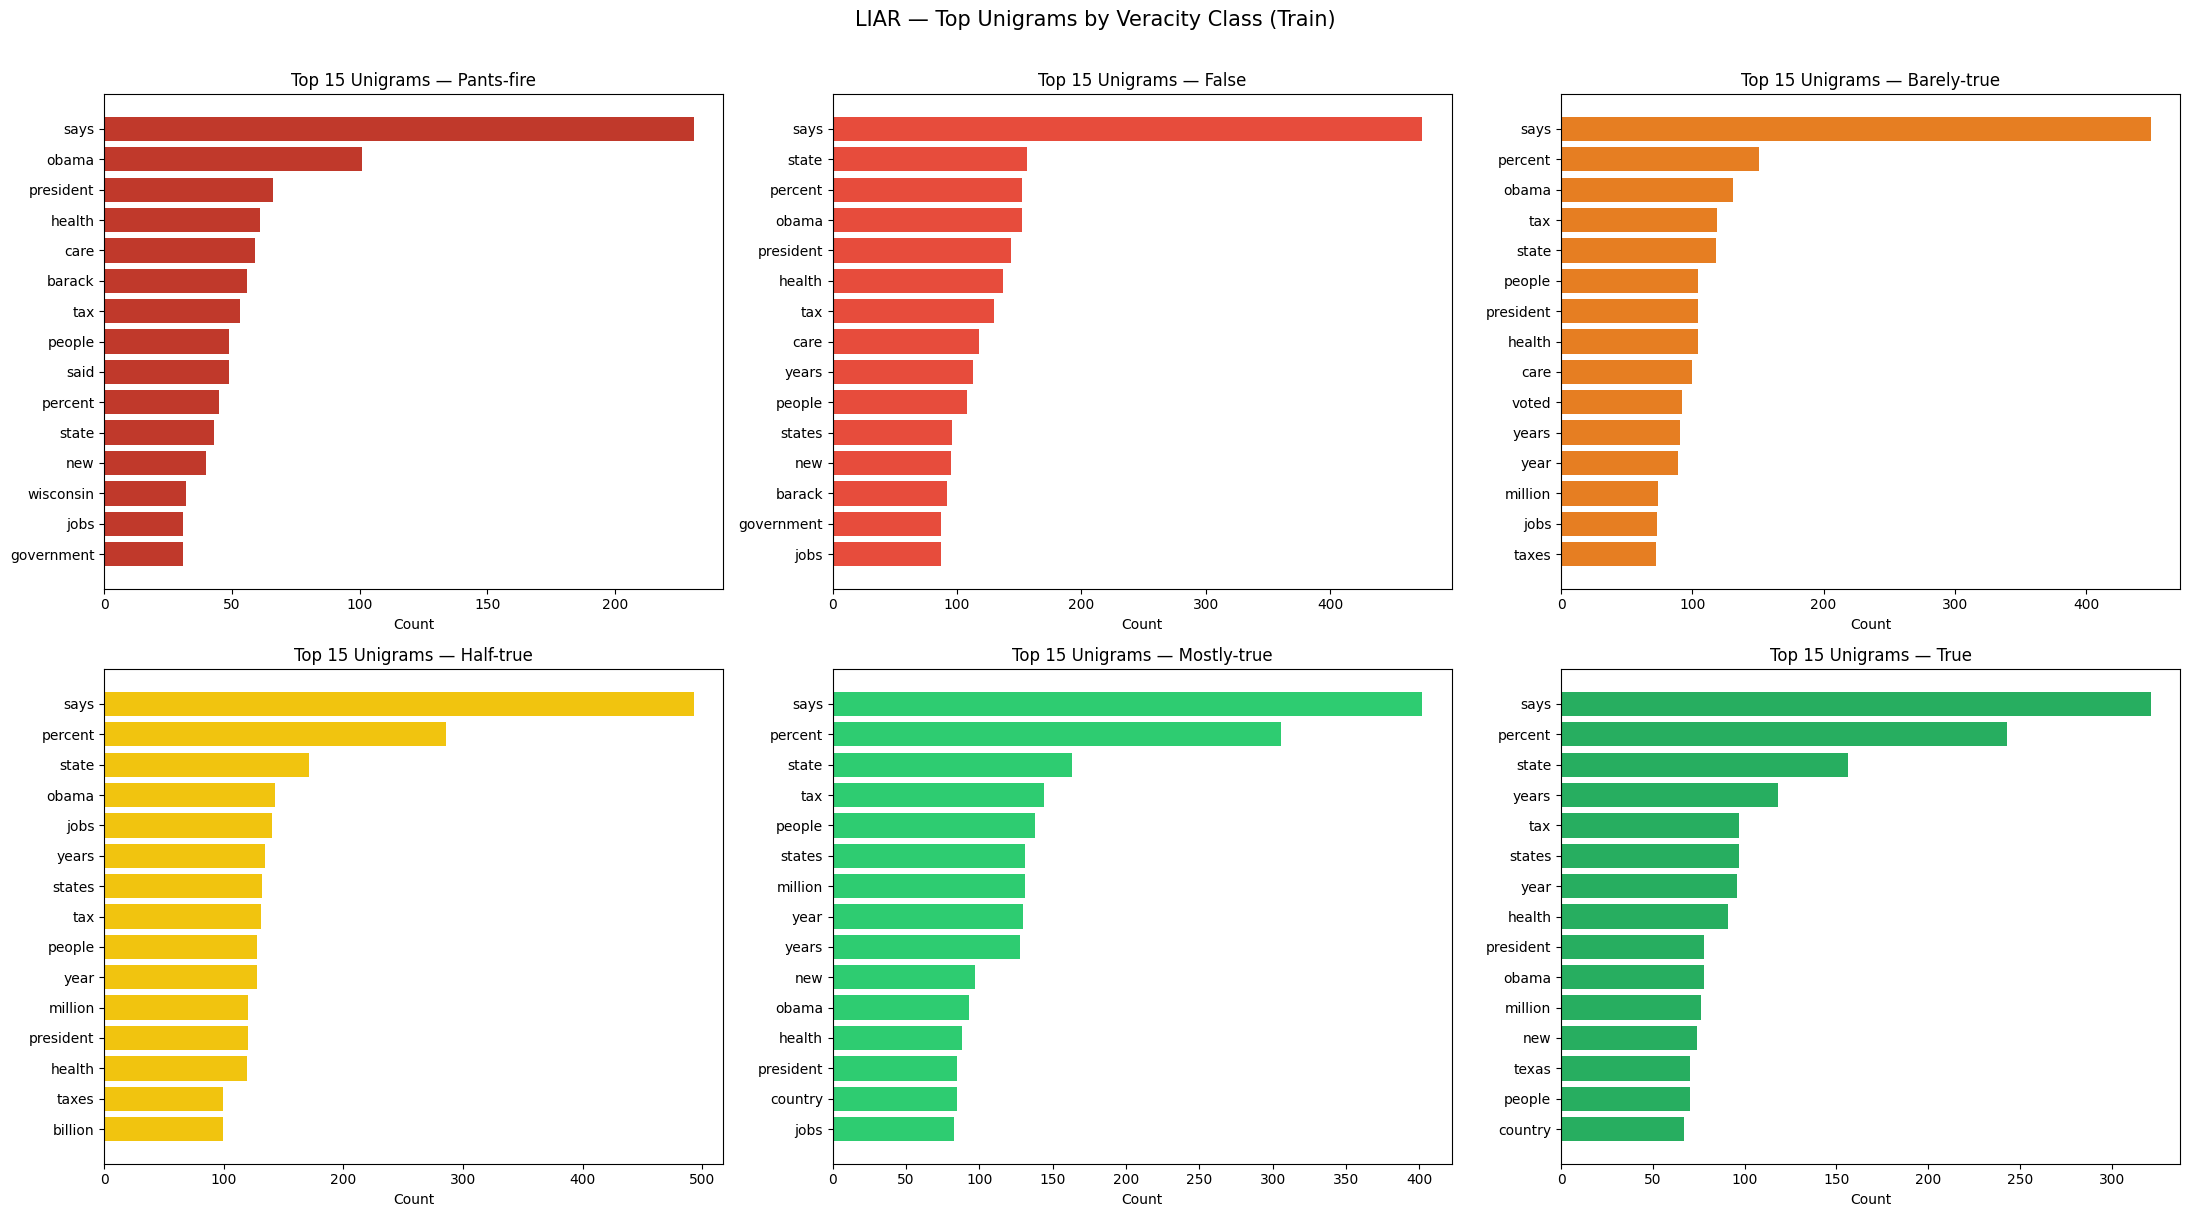

In [11]:
# Top 20 unigrams per veracity class
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_unigrams_liar(train_df, n_top=15):
    vectorizer = CountVectorizer(stop_words="english", max_features=5000)
    vectorizer.fit(train_df["text"])
    feature_names = vectorizer.get_feature_names_out()

    n_labels = 6
    n_cols = 3
    n_rows = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 12))
    axes = axes.flatten()

    for lbl in range(n_labels):
        ax = axes[lbl]
        subset = train_df[train_df["label"] == lbl]["text"]
        X = vectorizer.transform(subset)
        counts = X.sum(axis=0).A1
        top_idx = counts.argsort()[-n_top:][::-1]
        ax.barh(
            [feature_names[i] for i in top_idx][::-1],
            counts[top_idx][::-1],
            color=PALETTE[lbl]
        )
        ax.set_title(f"Top {n_top} Unigrams — {SHORT_NAMES[lbl]}")
        ax.set_xlabel("Count")

    plt.suptitle("LIAR — Top Unigrams by Veracity Class (Train)", fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

plot_top_unigrams_liar(train_df)

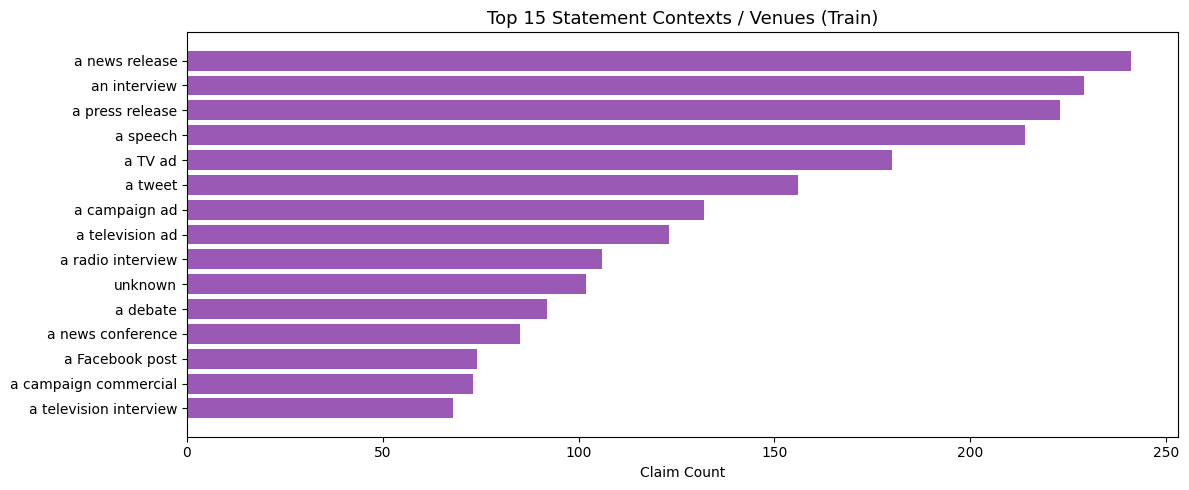

Top 15 contexts:
   241  a news release
   229  an interview
   223  a press release
   214  a speech
   180  a TV ad
   156  a tweet
   132  a campaign ad
   123  a television ad
   106  a radio interview
   102  unknown
    92  a debate
    85  a news conference
    74  a Facebook post
    73  a campaign commercial
    68  a television interview


In [13]:
# Context (venue) distribution — where were these statements made?
raw_context = raw["context"].fillna("unknown")
top_context = raw_context.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_context.index[::-1], top_context.values[::-1], color="#9b59b6")
ax.set_title("Top 15 Statement Contexts / Venues (Train)", fontsize=13)
ax.set_xlabel("Claim Count")
plt.tight_layout()
plt.show()

print("Top 15 contexts:")
for ctx, n in top_context.items():
    print(f"  {n:4d}  {ctx}")

In [15]:
# Stats summary — key numbers for the LIAR dataset
def print_stats_summary(train_df, val_df, test_df):
    for split_name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
        df = df.copy()
        df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
        mean_len  = df["text_length"].mean()
        p95_len   = df["text_length"].quantile(0.95)
        vocab     = len(set(" ".join(df["text"].dropna().astype(str)).split()))
        dist = df["label"].value_counts(normalize=True).sort_index()

        print(f"{split_name} Set:")
        print(f"  Rows:                    {len(df):,}")
        print(f"  Mean Statement Length:   {mean_len:.1f} words")
        print(f"  95th Percentile Length:  {p95_len:.0f} words")
        print(f"  Vocabulary Size:         {vocab:,}")
        print(f"  Class Balance:")
        for lbl, pct in dist.items():
            print(f"    {SHORT_NAMES[lbl]:12s} ({lbl}): {pct:.1%}")
        print()

print_stats_summary(train_df, val_df, test_df)

Train Set:
  Rows:                    10,240
  Mean Statement Length:   17.9 words
  95th Percentile Length:  33 words
  Vocabulary Size:         13,413
  Class Balance:
    Pants-fire   (0): 8.2%
    False        (1): 19.5%
    Barely-true  (2): 16.2%
    Half-true    (3): 20.6%
    Mostly-true  (4): 19.2%
    True         (5): 16.4%

Validation Set:
  Rows:                    1,284
  Mean Statement Length:   17.9 words
  95th Percentile Length:  32 words
  Vocabulary Size:         4,519
  Class Balance:
    Pants-fire   (0): 9.0%
    False        (1): 20.5%
    Barely-true  (2): 18.5%
    Half-true    (3): 19.3%
    Mostly-true  (4): 19.5%
    True         (5): 13.2%

Test Set:
  Rows:                    1,267
  Mean Statement Length:   18.3 words
  95th Percentile Length:  32 words
  Vocabulary Size:         4,527
  Class Balance:
    Pants-fire   (0): 7.3%
    False        (1): 19.7%
    Barely-true  (2): 16.7%
    Half-true    (3): 20.9%
    Mostly-true  (4): 19.0%
    True       